In [43]:
# The ever-growning import block
from itertools import combinations
from itertools import product
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.optimize import differential_evolution
from scipy.spatial.distance import cdist
from scipy.stats import qmc

#from sklearn.preprocessing import StandardScaler
#from sklearn.linear_model import LogisticRegression
#from sklearn.model_selection import train_test_split
#from sklearn.metrics import confusion_matrix, accuracy_score
#from sklearn.model_selection import GridSearchCV
#from sklearn.metrics import accuracy_score

import sys

# Find the shared helpers from the notebook folder or either repository root.
stage = next(
    stage
    for root in (Path.cwd(), *Path.cwd().parents)
    for stage in (root / "stage-2-bbo", root / "Capstone/imperial-capstone/stage-2-bbo")
    if (stage / "src/initial_exploration.py").is_file()
)
if str(stage / "src") not in sys.path:
    sys.path.insert(0, str(stage / "src"))

from initial_exploration import (
    load_initial_data, preview, plot_ranked_locations, plot_sampling_gaps,
    maximin_candidates_2d, maximin_comparison, plot_maximin_choice,
    coverage_value_comparison, average_coverage_summary, plot_average_coverage,
    plot_ordered_outputs,
)

figures = stage.parent / ".runtime/function-1-side-work"



In [20]:
# Where's the data?
# Working snapshot relative to the Stage 2 workspace.
data_path = str(stage / "side-work" / "function_3")
data_filename = "observations.csv"
full_data_path = data_path + "\\" + data_filename

In [21]:
# Basic data load
print("Loading data from: " + full_data_path)
data = pd.read_csv(full_data_path)
# The exploration plots label observations by output rank (1 = highest).
data["rank"] = data["y"].rank(ascending=False, method="min").astype(int)

Loading data from: C:\_Source\Imperial-ML-AI-Live\Capstone\imperial-capstone\side-work\function_3\observations.csv


In [22]:
# Column inspection
columns = data.columns
print("Columns: ", columns)

Columns:  Index(['observation_id', 'source_round', 'x1', 'x2', 'x3', 'y', 'rank'], dtype='str')


In [23]:
# Where we pray for good data, aka checking for nulls
print (data.isna().sum())

observation_id    0
source_round      0
x1                0
x2                0
x3                0
y                 0
rank              0
dtype: int64


In [24]:
# Splitting our data into inputs X and outputs y
output_column = "y"
input_columns = ["x1", "x2", "x3"]

print("Input columns: ", input_columns)
print("Output column: ", output_column)

X = data[input_columns]
y = data[output_column]

print("The inputs are given by :")
print(X.head())
print("The outputs are given by :")
print(y[:5])


Input columns:  ['x1', 'x2', 'x3']
Output column:  y
The inputs are given by :
         x1        x2        x3
0  0.171525  0.343917  0.248737
1  0.242114  0.644074  0.272433
2  0.534906  0.398501  0.173389
3  0.492581  0.611593  0.340176
4  0.134622  0.219917  0.458206
The outputs are given by :
0   -0.112122
1   -0.087963
2   -0.111415
3   -0.034835
4   -0.048008
Name: y, dtype: float64


In [25]:
# Ok, here is where we go into more problem-specific territory. 
# We are approaching this as primarily a Bayesian optimization problem where we need to balance exploration and exploitation. 
# We will use a Gaussian Process to model the underlying function and then use an acquisition function to decide where to sample next.
# But first, let's visualize the data to get a better understanding of the underlying function.



In [34]:
# Input space exploration visualisation
# Plot every unique pair of input dimensions, preserving their original names.
# Save the charts to disk; the next cell handles displaying them.

for pair in combinations(input_columns, 2):
    plot_ranked_locations(
        data,
        pair=pair,
        save_to=figures / f"ranked-locations-{'-'.join(pair)}.png",
    )

plt.close("all")

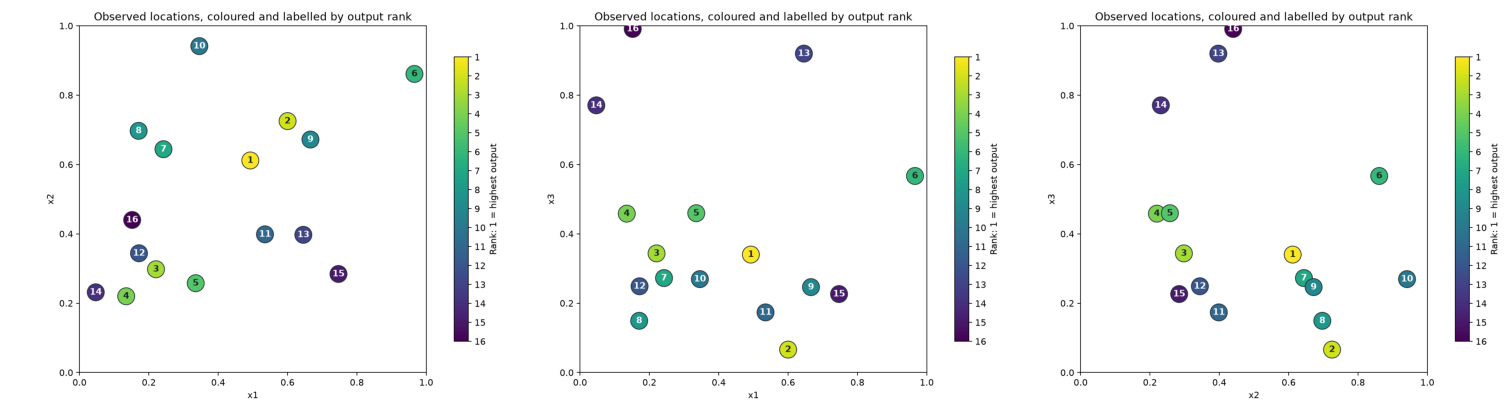

In [36]:
# Display every saved pairwise plot, wrapping onto additional rows as needed.
pairs = list(combinations(input_columns, 2))

if not pairs:
    raise ValueError("At least two input columns are needed for pairwise plots.")

columns = min(3, len(pairs))
rows = (len(pairs) + columns - 1) // columns

fig, axes = plt.subplots(
    rows,
    columns,
    figsize=(5 * columns, 5 * rows),
    layout="constrained",
    squeeze=False,
)

for ax, pair in zip(axes.flat, pairs):
    image = plt.imread(
        figures / f"ranked-locations-{'-'.join(pair)}.png"
    )
    ax.imshow(image)

# Hide the enclosing axes, including any unused panels.
# The saved charts already contain their own axes and labels.
for ax in axes.flat:
    ax.axis("off")    

fig.savefig(
    figures / "ranked-locations-combined.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

In [ ]:
# The most recent point is [x1=0.335102, x2=0.25754, x3=0.459461] : -0.0564311593911001
# That is 5th highest


In [38]:

# Input space coverage visualisation
# Plot every unique pair of input dimensions, preserving their original names.
# Save the charts to disk; the next cell handles displaying them.

for pair in combinations(input_columns, 2):
    plot_sampling_gaps(
        data,
        pair=pair,
        save_to=figures / f"sampling-gaps-{'-'.join(pair)}.png",
    )

plt.close("all")



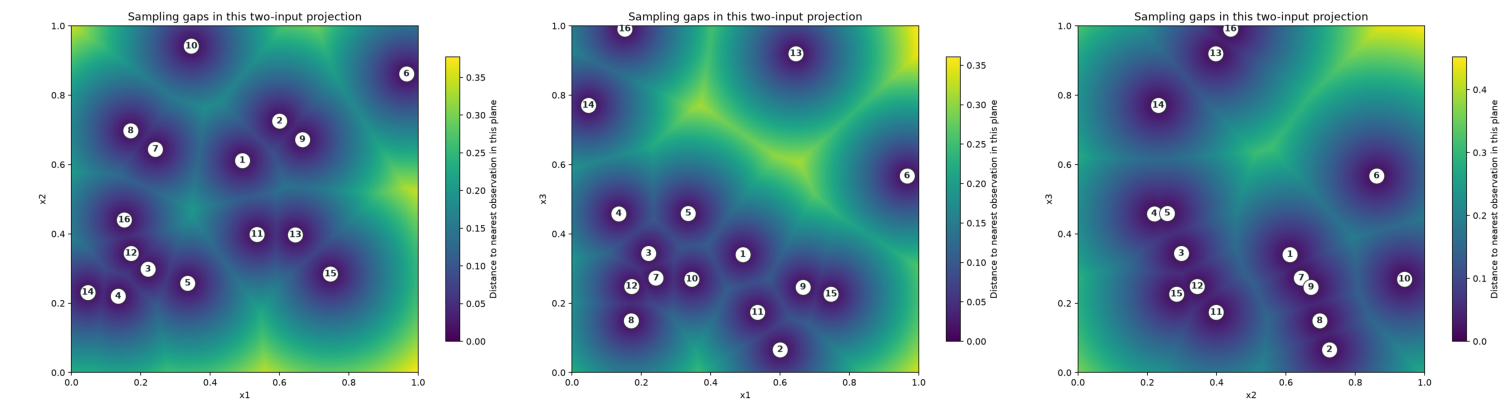

In [39]:
# Display every saved pairwise plot, wrapping onto additional rows as needed.
pairs = list(combinations(input_columns, 2))

if not pairs:
    raise ValueError("At least two input columns are needed for pairwise plots.")

columns = min(3, len(pairs))
rows = (len(pairs) + columns - 1) // columns

fig, axes = plt.subplots(
    rows,
    columns,
    figsize=(5 * columns, 5 * rows),
    layout="constrained",
    squeeze=False,
)

for ax, pair in zip(axes.flat, pairs):
    image = plt.imread(
        figures / f"sampling-gaps-{'-'.join(pair)}.png"
    )
    ax.imshow(image)

# Hide the enclosing axes, including any unused panels.
# The saved charts already contain their own axes and labels.
for ax in axes.flat:
    ax.axis("off")    

fig.savefig(
    figures / "sampling-gaps-combined.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

In [ ]:
# There are still some gaps in the input space that have not been sampled yet.
# Gut feel says to use one query on [x1= 0.5, x2= 0.6 , x3= 0.6]
# But the plan is to decide on a number of exploratory queries in advance, to even out information before beginning exploitation
# I'm expecting to see a reduction in perceived usefulness of exploration as dimensionality increases, but we will see if that is the case.

In [41]:
# Helpers for maximin candidate selection and comparison, and for coverage value comparison.
MAX_VALUE = 0.999999

def make_coverage_space(n_dimensions, power=12, seed=42):
    """Generate coverage-check points, including every corner."""

    sampler = qmc.Sobol(
        d=n_dimensions,
        scramble=True,
        rng=seed,
    )

    sampled_points = sampler.random_base2(m=power) * MAX_VALUE

    # Include the boundaries' corners explicitly:
    # only 256 corners even at eight dimensions.
    corners = np.array(
        list(product((0.0, MAX_VALUE), repeat=n_dimensions))
    )

    return np.vstack([sampled_points, corners])


def optimise_joint_minimax(existing, q, coverage_space, seed=42):
    n_dimensions = existing.shape[1]

    distance_to_existing = cdist(
        coverage_space,
        existing
    ).min(axis=1)

    def objective(flat_proposed):
        proposed = flat_proposed.reshape(q, n_dimensions)

        distance_to_proposed = cdist(
            coverage_space,
            proposed
        ).min(axis=1)

        nearest_distance = np.minimum(
            distance_to_existing,
            distance_to_proposed
        )

        return nearest_distance.max()

    result = differential_evolution(
        objective,
        bounds=[(0.0, MAX_VALUE)] * (q * n_dimensions),
        init="sobol",
        seed=seed,
        polish=True
    )

    return result.x.reshape(q, n_dimensions)

In [44]:
# Compare different numbers of additional exploratory candidates.
# Optimise each batch jointly, then assess its coverage 

n_dimensions = X.shape[1]

# 4,096 sampled points, plus the corners, for optimisation.
optimization_space = make_coverage_space(
    n_dimensions=n_dimensions,
    power=12,
    seed=42,
)

# 32,768 sampled points, plus the corners, for evaluation.
# A different seed gives a separate sample for assessing the results.
coverage_evaluation_space = make_coverage_space(
    n_dimensions=n_dimensions,
    power=15,
    seed=43,
)

results = []

for q in range(13):
    if q == 0:
        # Baseline: existing observations, with no additional candidates.
        proposed = np.empty((0, n_dimensions))
    else:
        proposed = optimise_joint_minimax(
            existing=X,
            q=q,
            coverage_space=optimization_space,
        )

    design = np.vstack([X, proposed])

    # Distance from each evaluation point to its nearest
    # existing observation or proposed candidate.
    distances = cdist(
        coverage_evaluation_space,
        design,
    ).min(axis=1)

    results.append({
        "q": q,
        "max_distance": distances.max(),
        "p95_distance": np.percentile(distances, 95),
    })

In [45]:
coverage_results = pd.DataFrame(results)
coverage_results

,q,max_distance,p95_distance
0,0,0.628240,0.439731
1,1,0.570499,0.389176
2,2,0.491711,0.364054
3,3,0.465230,0.360685
4,4,0.463653,0.358302
5,5,0.449714,0.341121
6,6,0.410118,0.328438
7,7,0.399298,0.310498
8,8,0.400720,0.314790
9,9,0.386919,0.310214


In [46]:
coverage_results["relative_max_distance"] = (
    coverage_results["max_distance"]
    / coverage_results.loc[0, "max_distance"]
)

coverage_results["coverage_improvement"] = (
    1.0 - coverage_results["relative_max_distance"]
)

coverage_results["marginal_improvement"] = (
    coverage_results["max_distance"]
    .shift(1)
    - coverage_results["max_distance"]
)

coverage_results

,q,max_distance,p95_distance,relative_max_distance,coverage_improvement,marginal_improvement
0,0,0.628240,0.439731,1.000000,0.000000,NaN
1,1,0.570499,0.389176,0.908091,0.091909,0.057741
2,2,0.491711,0.364054,0.782680,0.217320,0.078788
3,3,0.465230,0.360685,0.740528,0.259472,0.026481
4,4,0.463653,0.358302,0.738019,0.261981,0.001577
5,5,0.449714,0.341121,0.715832,0.284168,0.013939
6,6,0.410118,0.328438,0.652805,0.347195,0.039596
7,7,0.399298,0.310498,0.635582,0.364418,0.010821
8,8,0.400720,0.314790,0.637845,0.362155,-0.001422
9,9,0.386919,0.310214,0.615878,0.384122,0.013800


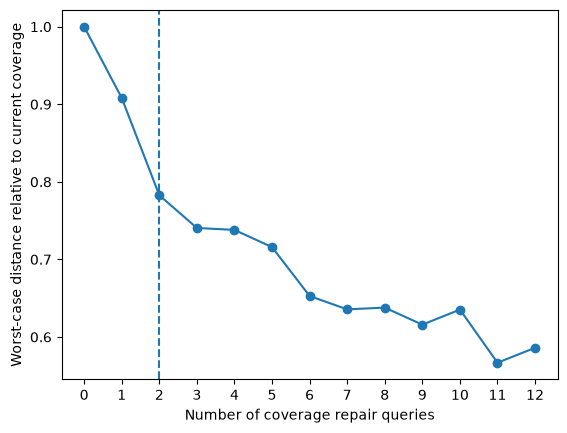

In [48]:

plt.plot(
    coverage_results["q"],
    coverage_results["relative_max_distance"],
    marker="o"
)

plt.axvline(2, linestyle="--")

plt.xlabel("Number of coverage repair queries")
plt.ylabel("Worst-case distance relative to current coverage")
plt.xticks(range(13))
plt.show()

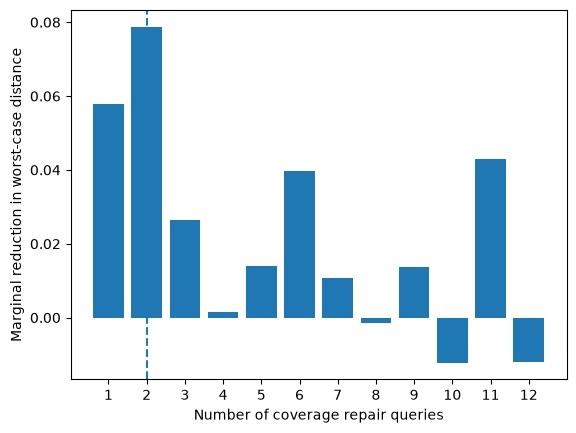

In [52]:
plt.bar(
    coverage_results["q"][1:],
    coverage_results["marginal_improvement"][1:]
)

plt.axvline(2, linestyle="--")

plt.xlabel("Number of coverage repair queries")
plt.ylabel("Marginal reduction in worst-case distance")
plt.xticks(range(1, 13))
plt.show()

In [ ]:
coverage_results["max_distance"].diff()

0          NaN
1    -0.141689
2    -0.054990
3    -0.053422
4    -0.003478
5    -0.042798
6    -0.011981
7    -0.000784
8    -0.025998
9    -0.017132
10   -0.001875
11    0.000000
12    0.000000
Name: max_distance, dtype: float64

In [53]:
best_q2 = None

for seed in range(50):
    proposed = optimise_joint_minimax(
        existing=X,
        q=2,
        coverage_space=optimization_space,
        seed=seed
    )

    design = np.vstack([X, proposed])

    distances = cdist(
        coverage_evaluation_space,
        design
    ).min(axis=1)

    score = distances.max()

    if best_q2 is None or score < best_q2["score"]:
        best_q2 = {
            "score": score,
            "proposed": proposed,
            "seed": seed
        }

In [54]:
coverage_queries = pd.DataFrame(
    best_q2["proposed"],
    columns=["x1", "x2", "x3"]
)

coverage_queries

,x1,x2,x3
0,0.376830,0.736530,0.882851
1,0.970535,0.230843,0.757933
